# Spectral Dimension Extraction for SM8 Cage Graph

This notebook loads the GPU‑generated return‑probability CSV and fits  
**P(t) ~ t^{-d_s/2}**  
to extract the spectral dimension **d_s**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load return‑probability CSV

In [13]:
df = pd.read_csv("nb02_SM8_600cell_2ring_return_prob.csv")

t_vals = df["t"].values
P_t = df["P"].values

print("Loaded", len(t_vals), "time steps")
print("Columns:", df.columns.tolist())

Loaded 2001 time steps
Columns: ['t', 'P']


## Plot return probability (log‑log)

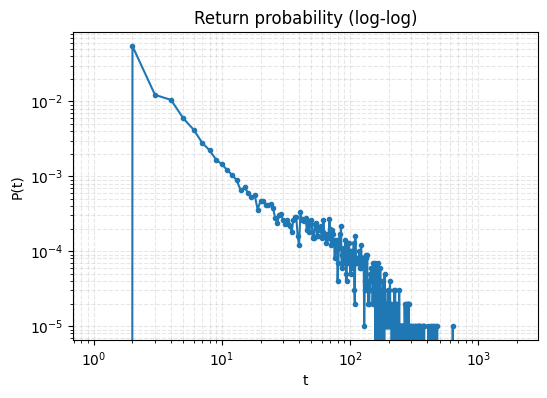

In [14]:
plt.figure(figsize=(6,4))
plt.loglog(t_vals[1:], P_t[1:], 'o-', markersize=3)
plt.xlabel("t")
plt.ylabel("P(t)")
plt.title("Return probability (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

## Choose scaling window

In [15]:
t_min, t_max = 50, 500
print("Scaling window:", t_min, "to", t_max)

mask = (df["t"] >= t_min) & (df["t"] <= t_max)
print("Number of points in window:", mask.sum())

Scaling window: 50 to 500
Number of points in window: 451


## Extract log–log data

In [16]:
# Extract log–log data, excluding zeros
t_window = df["t"][mask]
P_window = df["P"][mask]

# Remove zero or negative values (log-safe)
valid = P_window > 0
t_valid = t_window[valid]
P_valid = P_window[valid]

x = np.log(t_valid)
y = np.log(P_valid)

print("Valid points:", len(x))
print("log(t) range:", x.min(), "to", x.max())
print("log(P) range:", y.min(), "to", y.max())

Valid points: 227
log(t) range: 3.912023005428146 to 6.171700597410915
log(P) range: -11.512925464970229 to -8.2170885989659


## Fit slope and compute spectral dimension

In [17]:
slope, intercept = np.polyfit(x, y, 1)
d_s = -2 * slope

print(f"Slope m = {slope:.6f}")
print(f"Spectral dimension d_s = {d_s:.6f}")

Slope m = -1.766444
Spectral dimension d_s = 3.532887


## Plot fitted line

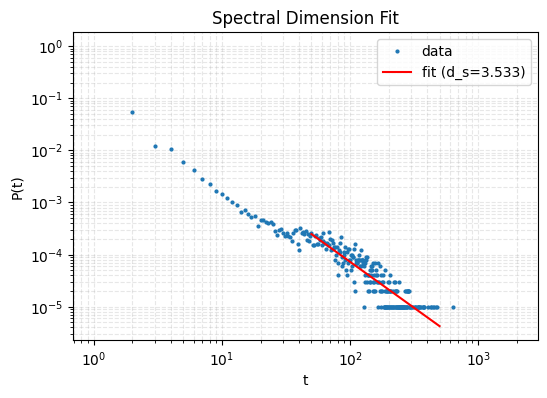

In [18]:
plt.figure(figsize=(6,4))
plt.loglog(df["t"], df["P"], 'o', markersize=2, label="data")

x_fit = np.linspace(np.log(t_min), np.log(t_max), 200)
y_fit = slope * x_fit + intercept
plt.loglog(np.exp(x_fit), np.exp(y_fit), 'r-', label=f"fit (d_s={d_s:.3f})")

plt.xlabel("t")
plt.ylabel("P(t)")
plt.legend()
plt.title("Spectral Dimension Fit")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

## Save processed data

In [19]:
output_path = "nb02_SM8_return_prob_data_current_graph_copy.csv"
df.to_csv(output_path, index=False)
print("Saved CSV to:", output_path)

Saved CSV to: nb02_SM8_return_prob_data_current_graph_copy.csv


In [20]:
print(f"Spectral dimension d_s = {d_s}")

Spectral dimension d_s = 3.5328872412655516


In [21]:
for (t_min, t_max) in [(40, 400), (60, 600), (80, 800), (100, 700)]:
    mask = (df["t"] >= t_min) & (df["t"] <= t_max)
    t_window = df["t"][mask]
    P_window = df["P"][mask]
    valid = P_window > 0
    x = np.log(t_window[valid])
    y = np.log(P_window[valid])
    slope, intercept = np.polyfit(x, y, 1)
    d_s = -2 * slope
    print(t_min, t_max, "→ d_s =", d_s)

40 400 → d_s = 3.576427712454466
60 600 → d_s = 3.5751494424524894
80 800 → d_s = 3.4089783718598436
100 700 → d_s = 3.346079522364773
